In [1]:
import pandas as pd

# Read the Excel file
transactions = pd.read_excel("QVI_transaction_data.xlsx")

# Convert to CSV format
transactions.to_csv("QVI_transaction_data.csv", index=False)

print("File successfully converted to CSV ")

File successfully converted to CSV 


Loading datasets

In [2]:

transactions = pd.read_csv("QVI_transaction_data.csv")
customers = pd.read_csv("QVI_purchase_behaviour.csv")

# Preview the data
transactions.head()
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


lets Check data structure

In [3]:
# Check dataset info
transactions.info()
customers.info()

# Check missing values
transactions.isnull().sum()
customers.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
m

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [4]:
# Convert DATE column to datetime format
transactions["DATE"] = pd.to_datetime(transactions["DATE"], origin="1899-12-30", unit="D")

# Check result
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


Removing outliers (data cleaning)

In [5]:
# Check unusual high quantity values
transactions[transactions["PROD_QTY"] > 10]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [6]:
# Remove extreme outliers in quantity
transactions = transactions[transactions["PROD_QTY"] <= 10]

In [7]:
# Merge transaction and customer data
data = pd.merge(transactions, customers, on="LYLTY_CARD_NBR", how="left")

# Check merged data
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


Feature Engineering

In [8]:
# Extract pack size from product name
data["PACK_SIZE"] = data["PROD_NAME"].str.extract("(\d+)").astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_7137/2723403364.py:2: SyntaxWarning: invalid escape sequence '\d'
  data["PACK_SIZE"] = data["PROD_NAME"].str.extract("(\d+)").astype(float)


In [9]:
# Extract brand (first word of product name)
data["BRAND"] = data["PROD_NAME"].str.split().str[0]

Create SALES column

In [10]:
# Calculate total sales per transaction
data["SALES"] = data["PROD_QTY"] * data["TOT_SALES"]

Basic Analysis

In [11]:
# Calculate total sales
total_sales = data["SALES"].sum()
print("Total Sales:", total_sales)

Total Sales: 3805472.700000001


Sales by customer segment

In [12]:
# Group by customer segments
segment_sales = data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["SALES"].sum().sort_values(ascending=False)

print(segment_sales)

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              335506.35
YOUNG SINGLES/COUPLES   Mainstream          304787.20
RETIREES                Mainstream          304550.85
YOUNG FAMILIES          Budget              277154.15
OLDER SINGLES/COUPLES   Budget              269690.30
                        Mainstream          262941.70
                        Premium             260992.15
RETIREES                Budget              221859.70
OLDER FAMILIES          Mainstream          206358.05
RETIREES                Premium             191809.35
YOUNG FAMILIES          Mainstream          184601.85
MIDAGE SINGLES/COUPLES  Mainstream          178914.75
YOUNG FAMILIES          Premium             166876.40
OLDER FAMILIES          Premium             160803.10
YOUNG SINGLES/COUPLES   Budget              117018.90
MIDAGE SINGLES/COUPLES  Premium             114594.05
YOUNG SINGLES/COUPLES   Premium              79609.30
MIDAGE SINGLES/COUPLES  Budget           

Customers per segment

In [18]:
data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique()

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Budget              1504
                        Mainstream          3340
                        Premium             2431
NEW FAMILIES            Budget              1112
                        Mainstream           849
                        Premium              588
OLDER FAMILIES          Budget              4675
                        Mainstream          2831
                        Premium             2273
OLDER SINGLES/COUPLES   Budget              4929
                        Mainstream          4930
                        Premium             4750
RETIREES                Budget              4454
                        Mainstream          6479
                        Premium             3872
YOUNG FAMILIES          Budget              4017
                        Mainstream          2728
                        Premium             2433
YOUNG SINGLES/COUPLES   Budget              3779
                        Mainstream          8088
                        Premium             2574
Name: LYLTY_CARD_NBR, dtype: int64

Units per customer

In [19]:
data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["PROD_QTY"].sum() / \
data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique()

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Budget              6.313830
                        Mainstream          6.796108
                        Premium             6.386672
NEW FAMILIES            Budget              5.009892
                        Mainstream          5.087161
                        Premium             5.028912
OLDER FAMILIES          Budget              9.639572
                        Mainstream          9.804309
                        Premium             9.578091
OLDER SINGLES/COUPLES   Budget              7.145466
                        Mainstream          7.098783
                        Premium             7.154947
RETIREES                Budget              6.458015
                        Mainstream          6.253743
                        Premium             6.426653
YOUNG FAMILIES          Budget              9.238486
                        Mainstream          9.180352
                        Premium             9.209207
YOUNG SINGLES/COUPLES   Budget              4.411485
                        Mainstream          4.776459
                        Premium             4.402098
dtype: float64

Price per unit

In [20]:
data["PRICE_PER_UNIT"] = data["TOT_SALES"] / data["PROD_QTY"]
data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["PRICE_PER_UNIT"].mean()

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Budget              3.728496
                        Mainstream          4.000101
                        Premium             3.752915
NEW FAMILIES            Budget              3.919251
                        Mainstream          3.916581
                        Premium             3.871743
OLDER FAMILIES          Budget              3.733344
                        Mainstream          3.727383
                        Premium             3.704625
OLDER SINGLES/COUPLES   Budget              3.877022
                        Mainstream          3.803800
                        Premium             3.887220
RETIREES                Budget              3.924883
                        Mainstream          3.833343
                        Premium             3.921323
YOUNG FAMILIES          Budget              3.753659
                        Mainstream          3.707097
                        Premium             3.752402
YOUNG SINGLES/COUPLES   Budget              3.637681
                        Mainstream          4.071485
                        Premium             3.645518
Name: PRICE_PER_UNIT, dtype: float64

Average transaction value:

In [13]:
# Calculate average spend per transaction
avg_transaction = data["SALES"].mean()
print("Average Transaction Value:", avg_transaction)

Average Transaction Value: 14.369275470672198


Visualization

Pack size analysis

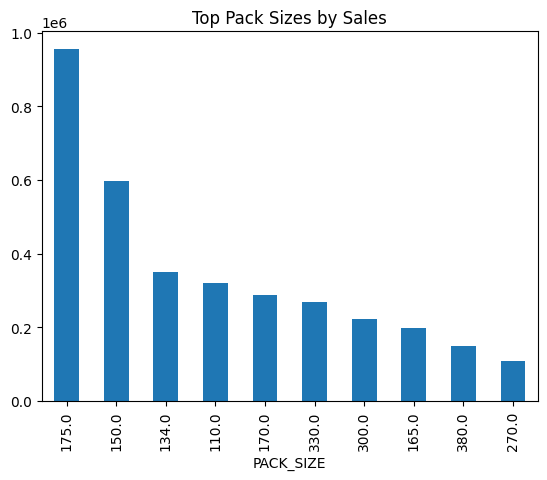

In [17]:
# Analyze sales by pack size
pack_sales = data.groupby("PACK_SIZE")["SALES"].sum().sort_values(ascending=False)

pack_sales.head(10).plot(kind="bar")

plt.title("Top Pack Sizes by Sales")
plt.show()

it Shows Who drives revenue

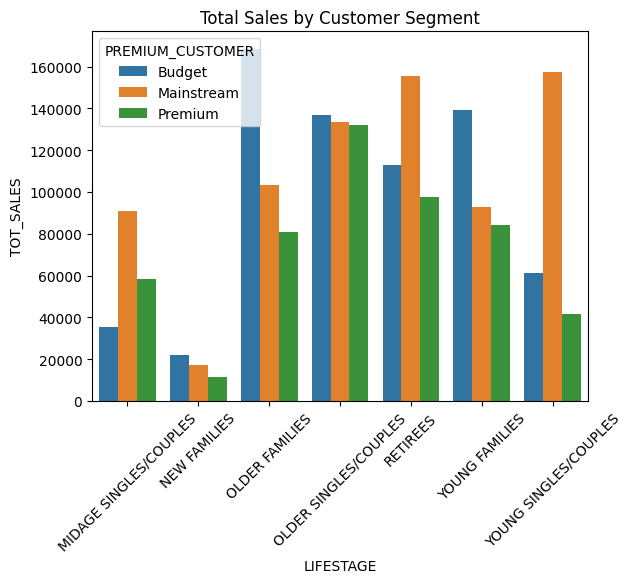

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sales = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"].sum().reset_index()

plt.figure()
sns.barplot(data=sales, x="LIFESTAGE", y="TOT_SALES", hue="PREMIUM_CUSTOMER")
plt.xticks(rotation=45)
plt.title("Total Sales by Customer Segment")
plt.show()

Older Families (Budget segment) generate the highest total sales, indicating they are the most valuable customer group.
Mainstream Young Singles/Couples also contribute significantly, driven by a large customer base.

 Number of Customers per Segment

it Shows Why sales are high?

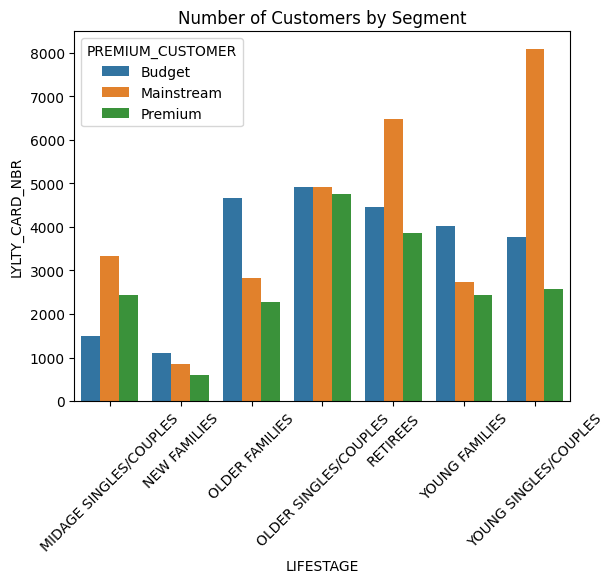

In [22]:
customers = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique().reset_index()

plt.figure()
sns.barplot(data=customers, x="LIFESTAGE", y="LYLTY_CARD_NBR", hue="PREMIUM_CUSTOMER")
plt.xticks(rotation=45)
plt.title("Number of Customers by Segment")
plt.show()

Young Singles/Couples (Mainstream) have the highest number of customers, explaining their strong contribution to total sales.

 Units per Customer

 Shows Who buys more

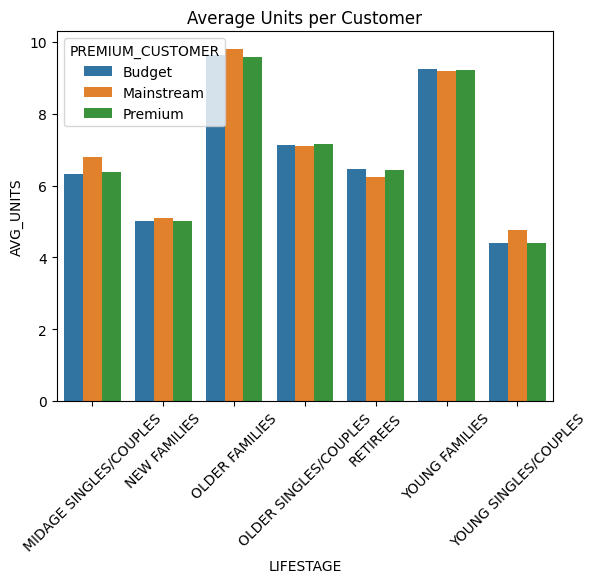

In [23]:
units = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["PROD_QTY"].sum() / \
        data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique()

units = units.reset_index(name="AVG_UNITS")

plt.figure()
sns.barplot(data=units, x="LIFESTAGE", y="AVG_UNITS", hue="PREMIUM_CUSTOMER")
plt.xticks(rotation=45)
plt.title("Average Units per Customer")
plt.show()

Older Families purchase the highest number of units per customer, suggesting bulk buying behavior.

 Price per Unit

 Shows Who pays more

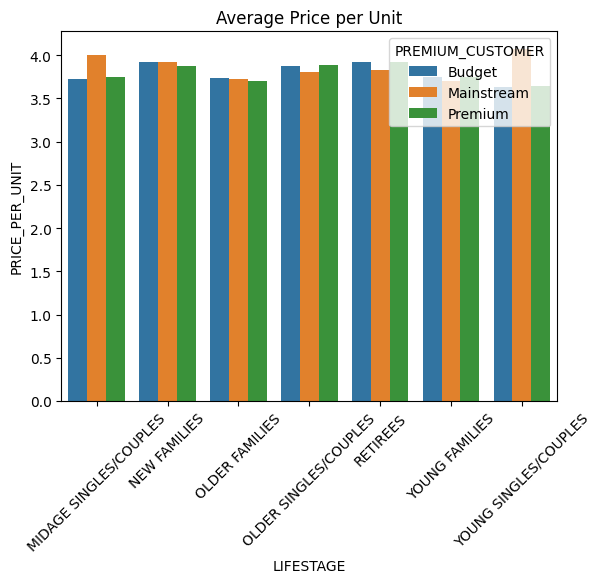

In [24]:
data["PRICE_PER_UNIT"] = data["TOT_SALES"] / data["PROD_QTY"]

price = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["PRICE_PER_UNIT"].mean().reset_index()

plt.figure()
sns.barplot(data=price, x="LIFESTAGE", y="PRICE_PER_UNIT", hue="PREMIUM_CUSTOMER")
plt.xticks(rotation=45)
plt.title("Average Price per Unit")
plt.show()

Mainstream customers tend to pay slightly higher prices per unit, indicating lower price sensitivity compared to Budget customers.

Conclusion

Sales are primarily driven by Older Families (Budget segment), Young Singles/Couples (Mainstream), and Retirees (Mainstream).

The high contribution from Young Singles/Couples (Mainstream) is largely due to their large customer base, making them a key volume driver. Similarly, Older Families (Budget) generate strong total sales because they tend to purchase more units per transaction, indicating bulk buying behavior.

We also observe that Mainstream customers (especially Young Singles/Couples and Midage groups) tend to pay a slightly higher price per unit, suggesting a greater willingness to spend and possible impulse purchasing behavior.

From the pack size analysis, standard sizes such as 175g dominate sales, indicating that customers prefer familiar and convenient pack sizes.

Business Recommendations

Based on these insights:

The business should target Older Families (Budget segment) with promotions and bundle offers, as they are high-volume buyers.
Marketing efforts should focus on Young Singles/Couples (Mainstream) to leverage their large population and strong contribution to total sales.
Product placement strategies (e.g., near checkout areas) can be optimized to encourage impulse purchases, especially for mainstream customers.
Inventory planning should prioritize high-performing pack sizes (e.g., 175g) to maximize sales efficiency.
Pricing strategies can be slightly optimized for Mainstream segments, who show a higher willingness to pay per unit.